# exp11 geometry visualizer

Two views:
1. **`plot_geometries(N)`** -- the exact ridge geometry for all six candidates at width `N` (grid points + faint ridge lines).
2. **`plot_error_heatmap(geometries, functions, N, ...)`** -- a pointwise `|error|` heatmap on the disk for the *saved best-lambda MLP*, so you can see WHERE each geometry interpolates well vs poorly. `geometries` and `functions` may each be a single name OR a list -> one subplot per (geometry, function) combination. If a single function is requested, its 3D surface is also shown above. White circle = unit (fit) disk; dashed circle = that geometry's halo extent.

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the '3d' projection)

# locate repo root (folder containing src/) and the exp11 geometries module
REPO = Path.cwd()
while not (REPO / 'src').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'experiments' / 'exp11_geometry_zoo_2d'))
from geometries import GEOMETRIES
from src.data.targets2d import get_target_2d

WEIGHTS_DIR = REPO / 'results' / 'exp11_geometry_zoo_2d' / 'weights'
RADIUS = 1.4   # default disk for the geometry shape view
LABELS = {
    'hex': '1) hex tangent', 'mode_radial': '2) mode-radial',
    'sixn_rings': '4) 6k-rings (aligned)', 'random_ridges': '5) random (3-ridge)',
    'radon_tensor': '6a) radon tensor', 'radon_interlaced': '6b) radon interlaced',
}

In [3]:
def plot_geometries(N, radius=RADIUS, seed=0, line_alpha=0.07):
    """2x3 panel of all six geometries at width N. Points prominent, lines faint."""
    theta = np.linspace(0, 2 * np.pi, 400)
    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    for ax, (name, fn) in zip(axes.ravel(), GEOMETRIES.items()):
        dirs, offs = fn(N, radius, seed=seed)
        pts = offs[:, None] * dirs                      # foot of perpendicular = t*w
        perp = np.column_stack([-dirs[:, 1], dirs[:, 0]])
        L = radius + 0.6
        segs = [[p - L * q, p + L * q] for p, q in zip(pts, perp)]
        ax.add_collection(LineCollection(segs, colors='tab:blue',
                                         alpha=line_alpha, linewidths=0.3, zorder=1))
        ax.scatter(pts[:, 0], pts[:, 1], s=11, zorder=3, edgecolors='none',
                   c=np.linalg.norm(pts, axis=1), cmap='viridis')
        ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=1.0, zorder=2)
        ax.plot(radius * np.cos(theta), radius * np.sin(theta), 'k--',
                lw=0.7, alpha=0.5, zorder=2)
        ax.set_aspect('equal')
        ax.set_xlim(-radius - 0.5, radius + 0.5)
        ax.set_ylim(-radius - 0.5, radius + 0.5)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'{LABELS.get(name, name)}   (ridges={len(offs)})', fontsize=12)
    fig.suptitle(f'exp11 ridge geometries at N = {N}', fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

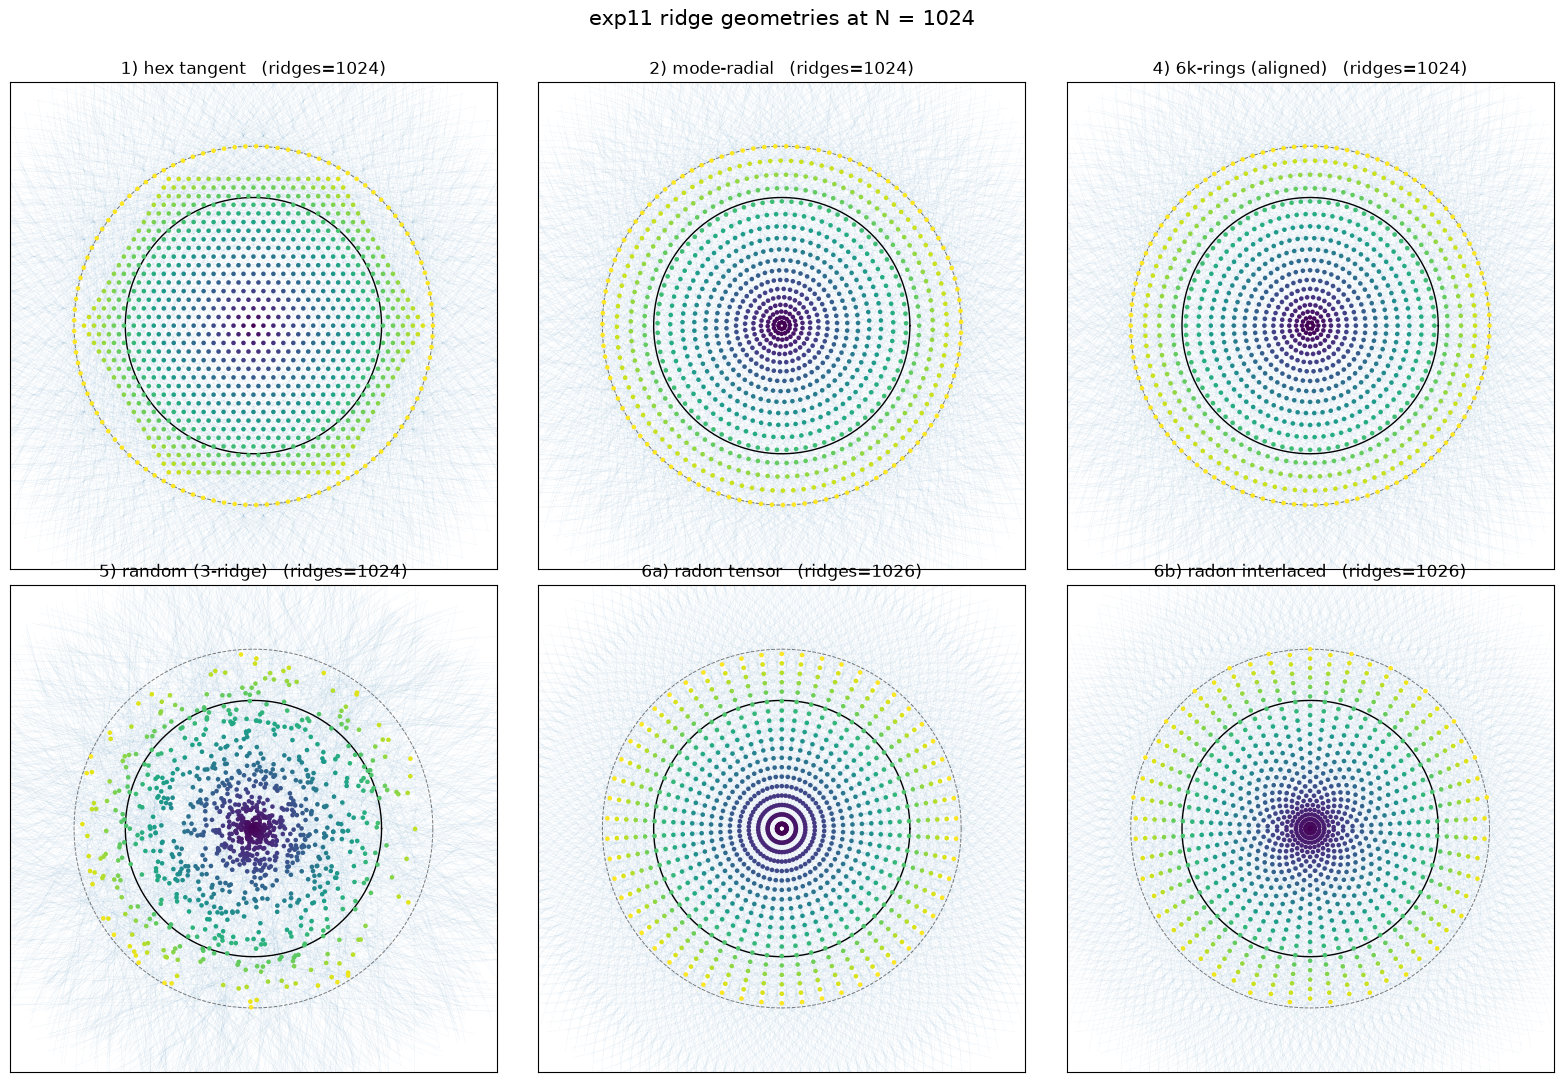

In [4]:
# Geometry shape view -- set N and re-run.
plot_geometries(1024)
plt.show()

## Error heatmap on the disk

Loads the saved best-lambda MLP `f(x) = bias + sum_m v_m * tanh(gamma*(w_m.x - t_m))` from `weights/` and plots `|f(x) - f_true(x)|` over the unit disk on a log color scale. `geometries` and `functions` are each a single name or a **list** -> one subplot per (geometry, function) combination. A single function also gets a 3D surface plot above. Available: geometries above; `N in {64,144,256,576,1024,2048,4096,8192}`; functions `gauss_bump, runge2d, sine2d, mixed2d`.

In [5]:
def plot_error_heatmap(geometries, functions, N, metric='linf',
                       show_points=False, grid=320, point_size=3, ncols=None):
    """Pointwise |error| heatmap on the disk for the SAVED best-lambda MLP(s).
    `geometries` and `functions` may each be a single name OR a list; a subplot
    is drawn for every (geometry, function) combination. The heatmap is always
    |f_hat - f_true| on a log color scale, so you see WHERE the error lives;
    `metric` ('linf' | 'l2') only sets the scalar printed in each title. If a
    single function is requested, its 3D target surface is also shown in a figure
    above. White circle = unit (fit) disk; dashed circle = that geometry's halo
    extent; `show_points` overlays small blue grid points (out to the halo)."""
    if isinstance(geometries, str):
        geometries = [geometries]
    if isinstance(functions, str):
        functions = [functions]

    # 3D surface of the target (only when a single function is requested).
    if len(functions) == 1:
        func0 = functions[0]
        g3 = np.linspace(-1, 1, 200)
        X3, Y3 = np.meshgrid(g3, g3)
        flat3 = np.stack([X3.ravel(), Y3.ravel()], axis=1)
        in3 = flat3[:, 0] ** 2 + flat3[:, 1] ** 2 <= 1.0
        Z3 = np.where(in3, get_target_2d(func0).fn_numpy(flat3), np.nan).reshape(200, 200)
        fig3 = plt.figure(figsize=(7, 5.5))
        ax3 = fig3.add_subplot(111, projection='3d')
        ax3.plot_surface(X3, Y3, Z3, cmap='viridis', linewidth=0, antialiased=True,
                         rcount=140, ccount=140)
        ax3.set_title(f'target function: {func0}', fontsize=13)
        ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel(func0)

    cells = [(geom, func) for geom in geometries for func in functions]
    if ncols is None:
        ncols = min(len(cells), 3)
    nrows = int(np.ceil(len(cells) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.8 * ncols, 5.6 * nrows),
                             squeeze=False)
    g = np.linspace(-1, 1, grid)
    XX, YY = np.meshgrid(g, g)
    flat = np.stack([XX.ravel(), YY.ravel()], axis=1)
    inside = flat[:, 0] ** 2 + flat[:, 1] ** 2 <= 1.0
    th = np.linspace(0, 2 * np.pi, 400)
    for idx, (geom, func) in enumerate(cells):
        ax = axes[idx // ncols][idx % ncols]
        f = WEIGHTS_DIR / f'{geom}_N{N}_{func}.npz'
        if not f.exists():
            ax.text(0.5, 0.5, f'no weights for\n{geom}\nN={N}, {func}',
                    ha='center', va='center'); ax.axis('off'); continue
        z = np.load(f)
        dirs, offs = z['dirs'], z['offsets']
        gamma, v, bias, R = float(z['gamma']), z['v'], float(z['bias']), float(z['radius'])
        fhat = bias + np.tanh(gamma * (flat @ dirs.T - offs[None, :])) @ v
        ytrue = get_target_2d(func).fn_numpy(flat)
        err = np.full(flat.shape[0], np.nan)
        err[inside] = np.abs(fhat[inside] - ytrue[inside])
        err = err.reshape(grid, grid)
        emin = max(np.nanmin(err), 1e-16); emax = max(np.nanmax(err), emin * 10)
        cmap = plt.cm.inferno.copy(); cmap.set_bad('#eeeeee')
        im = ax.pcolormesh(XX, YY, err, norm=LogNorm(vmin=emin, vmax=emax),
                           cmap=cmap, shading='auto')
        ax.plot(np.cos(th), np.sin(th), 'w-', lw=1.4, zorder=4)                       # unit (fit) disk
        ax.plot(R * np.cos(th), R * np.sin(th), 'k--', lw=0.9, alpha=0.6, zorder=4)   # halo extent
        if show_points:
            cp = offs[:, None] * dirs
            ax.scatter(cp[:, 0], cp[:, 1], s=point_size, c='blue', edgecolors='none', zorder=5)
        mval = float(z['linf']) if metric == 'linf' else float(z['rel_l2'])
        mlab = 'Linf' if metric == 'linf' else 'rel L2'
        ax.set_title(f'{geom}  |  {func}  |  N={N}\n{mlab} = {mval:.2e}', fontsize=10)
        ax.set_aspect('equal')
        ax.set_xlim(-R - 0.2, R + 0.2); ax.set_ylim(-R - 0.2, R + 0.2)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('#eeeeee')
        fig.colorbar(im, ax=ax, shrink=0.82, label='|error|')
    for j in range(len(cells), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    fig.suptitle(f'Error heatmap on the disk -- N={N}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

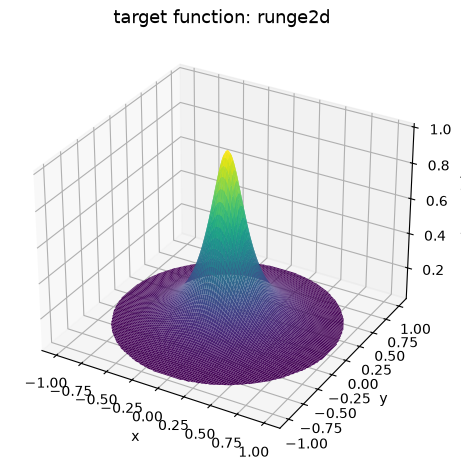

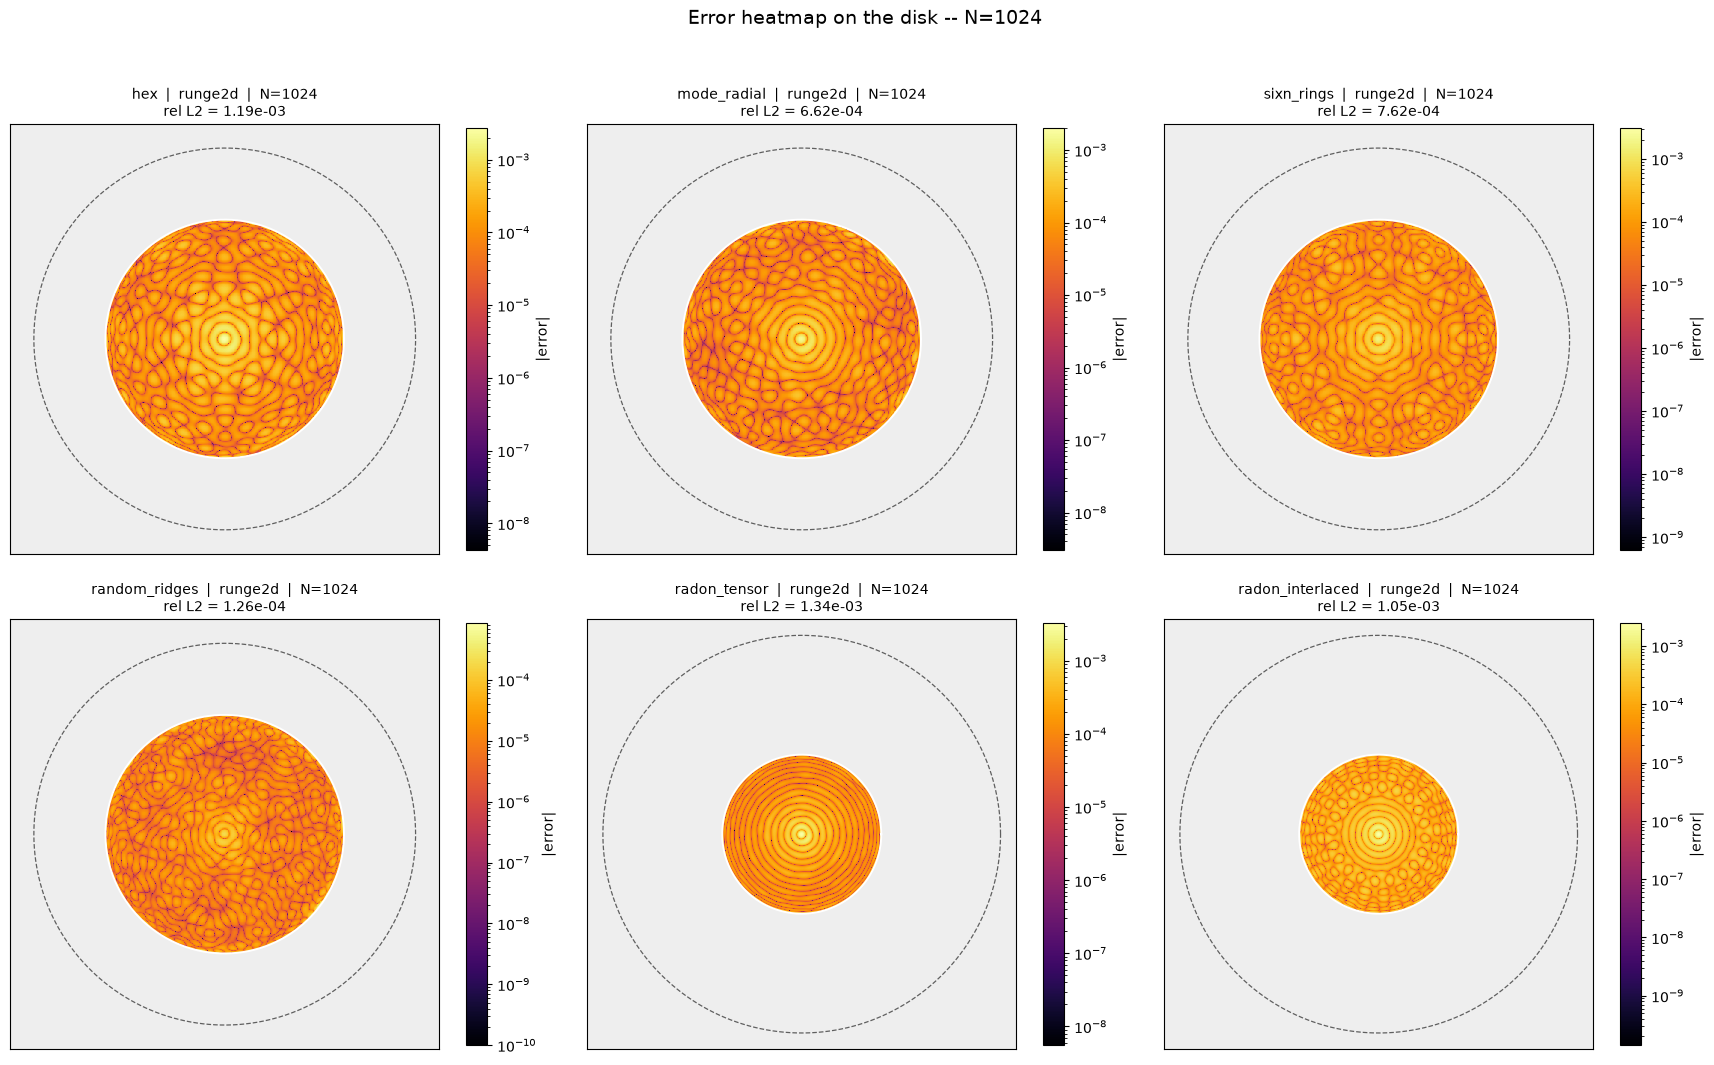

In [6]:
# ===== options (edit and run) =====
# geometries  : 'hex' | 'mode_radial' | 'sixn_rings' | 'random_ridges'
#               | 'radon_tensor' | 'radon_interlaced'   (a single name OR a list)
# functions   : 'gauss_bump' | 'runge2d' | 'sine2d' | 'mixed2d'   (single OR list)
#               -> a subplot is drawn for every (geometry, function) combination;
#                  a SINGLE function also gets a 3D target surface above
# N           : 64 | 144 | 256 | 576 | 1024 | 2048 | 4096 | 8192
# metric      : 'linf' | 'l2'   (scalar shown in each title; heatmap is always |error|)
# show_points : True | False    (overlay small blue grid points, out to the halo)
#
# plot_error_heatmap('hex', 'gauss_bump', N=1024, metric='l2', show_points=True)
# plot_error_heatmap('radon_tensor', ['gauss_bump','sine2d','runge2d','mixed2d'], N=4096)

# all six geometries on one function (compare geometries; 3D surface shown above):
plot_error_heatmap(['hex', 'mode_radial', 'sixn_rings', 'random_ridges',
                    'radon_tensor', 'radon_interlaced'],
                   'runge2d', N=1024, metric='l2', show_points=False)
plt.show()